# Run Hypertuning of RNN model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [14]:
import rpy2.robjects as robjects
import numpy as np

readRDS = robjects.r['readRDS']

# Load a 3D array (e.g. X_train has shape [samples, lookback, features])
X_train = np.array(robjects.r["values"](readRDS("energy_data/X_train.rds")))
Y_train = np.array(robjects.r["values"](readRDS("energy_data/Y_train.rds")))


KeyError: "'values' not found"

In [ ]:
import rpy2.robjects as robjects

folder_name = 'energy_data'
n_states = 3

# Helper function to convert R data.frame to pandas DataFrame
def r_to_df(r_df):
    return pd.DataFrame({name: np.array(r_df.rx2(name)) for name in r_df.names})

# Read the RDS files using rpy2
readRDS = robjects.r['readRDS']
dimnames_r = robjects.r["dimnames"]
values_r = robjects.r["values"]

dim_names = list(dimnames_r(readRDS(folder_name + "/X_train.rds"))[2])
print("Dim names of X_train:", dim_names)

X_train_orig = np.array(readRDS(folder_name + "/X_train.rds"))
Y_train_orig = np.array(readRDS(folder_name + "/Y_train.rds"))
X_valid_orig = np.array(readRDS(folder_name + "/X_valid.rds"))
Y_valid_orig = np.array(readRDS(folder_name + "/Y_valid.rds"))
X_test_orig = np.array(readRDS(folder_name + "/X_test.rds"))
Y_test_orig = np.array(readRDS(folder_name + "/Y_test.rds"))

hmm_pred_train = np.array(readRDS(folder_name + "/Y_hat_train.rds"))
hmm_pred_valid = np.array(readRDS(folder_name + "/Y_hat_valid.rds"))
hmm_pred_test = np.array(readRDS(folder_name + "/Y_hat_test.rds"))

hmm_transition_matrix = pd.read_csv(folder_name + "/transition_matrix.csv")

last_state_test = X_test_orig[:, -1, 2:n_states+1]
last_state_valid = X_valid_orig[:, -1, 2:n_states+1]

X_train_orig.shape, Y_train_orig.shape, X_valid_orig.shape, Y_valid_orig.shape, X_test_orig.shape, Y_test_orig.shape

Dim names of X_train: ['date', 'renewable_penetration', 'renewable_penetration_30d_avg', 'gas_share', 'gas_share_30d_avg', 'coal_share', 'coal_share_30d_avg', 'net_export_ratio', 'relative_demand', 'gas_price', 'month', 'day_of_week', 'state_prob_1', 'state_prob_2', 'state_prob_3']


IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

In [13]:
robjects.r["values"](readRDS(folder_name + "/X_train.rds"))

KeyError: "'values' not found"

In [3]:
forecast_horizon = Y_train_orig.shape[1]

# Create a function to prepare data for all splits
def prepare_data_with_horizon(X, Y, shuffle=True):

    # Create one-hot encoded horizon inputs
    horizon_input = np.eye(forecast_horizon)
    horizon_input = np.repeat(horizon_input, X.shape[0], axis=0)

    # Repeat X for each forecast horizon
    X = np.concatenate([X for i in range(forecast_horizon)], axis=0)
    # Get Y for each forecast horizon
    Y = np.concatenate([Y[:, i, :] for i in range(forecast_horizon)], axis=0)
    
    # Shuffle the rows of X, horizon_input, and Y in the same order using numpy
    if shuffle:
        idx = np.random.permutation(X.shape[0])
        X = X[idx]
        horizon_input = horizon_input[idx]
        Y = Y[idx]
    return X, horizon_input, Y

# Prepare validation and test data
X_train_full, horizon_train, Y_train = prepare_data_with_horizon(X_train_orig, Y_train_orig, shuffle=True)
X_valid_full, horizon_valid, Y_valid = prepare_data_with_horizon(X_valid_orig, Y_valid_orig, shuffle=False)
X_test_full, horizon_test, Y_test = prepare_data_with_horizon(X_test_orig, Y_test_orig, shuffle=False)

X_train_full.shape, horizon_train.shape, Y_train.shape, X_valid_full.shape, horizon_valid.shape, Y_valid.shape, X_test_full.shape, horizon_test.shape, Y_test.shape

((35300, 10, 13),
 (35300, 10),
 (35300, 3),
 (7670, 10, 13),
 (7670, 10),
 (7670, 3),
 (7670, 10, 13),
 (7670, 10),
 (7670, 3))

In [4]:
X_train = X_train_full
X_valid = X_valid_full
X_test = X_test_full

### Define the model

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
from tensorflow.keras.losses import kullback_leibler_divergence
from tensorflow.keras.layers import Concatenate

# Assuming X_train, Y_train, X_valid, Y_valid, and n_states are defined elsewhere
# lookback and forecast_horizon are provided but not directly used in model building

# Compute Dirichlet parameters and predicted probabilities (for reference, not used in model)
def dirichlet_layer(evidence):
    alpha = evidence + 1
    S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
    probs = alpha / S
    return probs, alpha, S

# Custom evidential loss with annealing
class EvidentialLoss(tf.keras.losses.Loss):
    def __init__(self, annealing_rate=100.0, max_annealing_rate=0.2, name='evidential_loss'):
        super().__init__(name=name)
        self.annealing_rate = tf.constant(annealing_rate, dtype=tf.float32)
        self.max_annealing_rate = tf.constant(max_annealing_rate, dtype=tf.float32)
        self.current_epoch = tf.Variable(0.0, trainable=False, dtype=tf.float32)
    
    def call(self, y_true, evidence):
        alpha = evidence + 1
        S = tf.reduce_sum(alpha, axis=-1, keepdims=True)
        probs = alpha / S
        
        # Classification error: categorical cross-entropy for soft probability targets
        err = tf.keras.losses.categorical_crossentropy(y_true, probs)

        var = tf.reduce_sum(probs * (1 - probs) / (S + 1), axis=-1, keepdims=True)
        
        # Annealing factor for the regularization term
        lambda_ = tf.minimum(self.max_annealing_rate, self.current_epoch / self.annealing_rate)
        
        return tf.reduce_mean(err + lambda_ * var, axis=-1)

# Custom callback to update the current epoch in the loss instance
class AnnealingCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        if hasattr(self.model, 'loss') and isinstance(self.model.loss, EvidentialLoss):
            self.model.loss.current_epoch.assign(tf.cast(epoch, tf.float32))

# Custom metric using KL divergence
def evidential_kl_divergence(y_true, y_pred):
    probs, _, _ = dirichlet_layer(y_pred)  # Derive probabilities from evidence
    return kullback_leibler_divergence(y_true, probs)

def cross_entropy_loss(y_true, y_pred):
    probs, _, _ = dirichlet_layer(y_pred)  # Derive probabilities from evidence
    return tf.keras.losses.categorical_crossentropy(y_true, probs)

## Run hypertuning

In [41]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Concatenate

# Model-building function for hyperparameter tuning
def build_model(hp):
    
    # Tune lookback (history length/timesteps)
    lookback = hp.Choice('lookback', values=[10])
    
    # Tune feature inclusion (one boolean per group of 4 columns)
    include_log_return_VWAP = True # hp.Boolean('include_log_return_VWAP', default=True)
    include_log_demand = True # hp.Boolean('include_log_demand', default=True)
    include_renewable_penetration = True # hp.Boolean('include_renewable_penetration', default=True)
    include_gas_share = True # hp.Boolean('include_gas_share', default=True)
    include_coal_share = True # hp.Boolean('include_coal_share', default=True)
    include_net_export_ratio = True # hp.Boolean('include_net_export_ratio', default=True)
    include_net_load = True # hp.Boolean('include_net_load', default=True)
    include_demand_growth = True # hp.Boolean('include_demand_growth', default=True)
    include_month = True # hp.Boolean('include_month', default=True)
    include_day_of_week = True # hp.Boolean('include_day_of_week', default=True)
    include_hmm_states = True
    
    # Build feature mask: 1.0 for included groups, 0.0 for excluded
    feature_mask_list = (
        [1.0] if include_log_return_VWAP else [0.0]
    ) + (
        [1.0] if include_log_demand else [0.0]
    ) + (
        [1.0] if include_renewable_penetration else [0.0]
    ) + (
        [1.0] if include_gas_share else [0.0]
    ) + (
        [1.0] if include_coal_share else [0.0]
    ) + (
        [1.0] if include_net_export_ratio else [0.0]
    ) + (
        [1.0] if include_net_load else [0.0]
    ) + (
        [1.0] if include_demand_growth else [0.0]
    ) + (
        [1.0] if include_month else [0.0]
    ) + (
        [1.0] if include_day_of_week else [0.0]
    ) + (
        [1.0] * n_states if include_hmm_states else [0.0] * n_states
    )
    feature_mask = tf.constant(feature_mask_list, dtype=tf.float32)
    
    # Other hyperparameters (unchanged)
    rnn_units = hp.Choice('rnn_units', values=[4])
    dense_units = hp.Choice('dense_units', values=[8, 16, 32])
    dropout_rate = hp.Choice('dropout_rate', values=[0.3])
    # Tune embedding dimension for horizon input
    embedding_dim = hp.Choice('embedding_dim', values=[4])
    #learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3])
    annealing_rate = hp.Choice('annealing_rate', values=[100.0])
    max_annealing_rate = hp.Choice('max_annealing_rate', values=[0.1, 0.2])

    # Primary input for timeseries data
    timeseries_input = layers.Input(shape=X_train.shape[1:])
    
    # Auxiliary input for one-hot encoded horizon (length 10)
    horizon_input = layers.Input(shape=(10,))
    
    # Embed the horizon input into a dense representation
    horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)
    
    # Lambda layer to slice to the last 'lookback' timesteps
    sliced = layers.Lambda(lambda x: x[:, -lookback:, :])(timeseries_input)
    
    # Lambda layer to apply feature mask (broadcast to (batch, timesteps, 20))
    masked = layers.Lambda(lambda x: x * tf.reshape(feature_mask, (1, 1, X_train.shape[2])))(sliced)
    
    # LSTM layer with added dropout
    lstm_out = layers.SimpleRNN(rnn_units, dropout=dropout_rate)(masked)
    
    # Concatenate LSTM output with embedded horizon
    concat = Concatenate()([lstm_out, horizon_embed])
    
    # Dense layers following concatenation
    dense1 = layers.Dense(dense_units, activation='relu')(concat)
    drop1 = layers.Dropout(dropout_rate)(dense1)
    dense2 = layers.Dense(dense_units, activation='relu')(drop1)
    drop2 = layers.Dropout(dropout_rate)(dense2)
    
    # Output raw evidence (non-negative)
    output = layers.Dense(n_states, activation='softplus')(drop2)
    
    # Define the multi-input model
    model = models.Model(inputs=[timeseries_input, horizon_input], outputs=output)
    
    model.compile(
        loss=EvidentialLoss(annealing_rate=annealing_rate, max_annealing_rate=max_annealing_rate),
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        metrics=[evidential_kl_divergence, cross_entropy_loss]  # Accuracy on argmax(probs)
    )
    
    return model

In [43]:
tf.keras.backend.clear_session()

# Initialize the tuner using GridSearch (exhaustive grid search over all combinations)
tuner = kt.GridSearch(
    build_model,
    objective=kt.Objective(name='val_loss', direction='min'), 
    max_trials=None,                    # None = evaluate every combination
    directory='energy_tuner_dir',
    project_name='energy_rnn_tuning_grid_round_3',
    seed=42
)

# Define callbacks: annealing and early stopping
annealing_callback = AnnealingCallback()
#early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Perform the hyperparameter search
tuner.search(
    [X_train, horizon_train], 
    Y_train, 
    epochs=30, 
    validation_data=([X_valid, horizon_valid], Y_valid),
    callbacks=[annealing_callback],
    verbose=1  # Adjust verbosity as needed
)

# Retrieve the best model and hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=3)[0]

# Optionally, print the best hyperparameters
print(best_hyperparameters.values)

# Summary of the best model
best_model.summary()

Trial 6 Complete [00h 01m 13s]
val_loss: 0.9837860465049744

Best val_loss So Far: 0.970578670501709
Total elapsed time: 00h 07m 18s
{'lookback': 10, 'rnn_units': 4, 'dense_units': 32, 'dropout_rate': 0.3, 'embedding_dim': 4, 'annealing_rate': 100.0, 'max_annealing_rate': 0.1}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 10, 13)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 10, 13)    │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 4)         │         72 │ lambda_1[0][0]    │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │         44 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8)         │          0 │ simple_rnn[0][0], │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      1,056 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         99 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,559 (6.09 KB)

 Trainable params: 1,559 (6.09 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
import pandas as pd

# Retrieve the top 10 trials from the tuner's oracle, sorted by the objective (lowest val_evidential_kl_divergence)
best_trials = tuner.oracle.get_best_trials(num_trials=20)

# Prepare a list to hold the data for the DataFrame
data = []

# Iterate over each trial to extract hyperparameters and score
for trial in best_trials:
    # Copy the hyperparameter values as a dictionary
    hp_values = trial.hyperparameters.values.copy()
    # Add the score (val_evidential_kl_divergence) to the dictionary
    hp_values['val_loss'] = trial.score
    # Append to the list
    data.append(hp_values)

# Create the DataFrame from the list of dictionaries
df = pd.DataFrame(data)

# Optionally, sort or reorder columns if needed (e.g., move score to the front)
df = df[['val_loss'] + [col for col in df.columns if col != 'val_loss']]

# Display or save the DataFrame
df

,val_loss,lookback,rnn_units,dense_units,dropout_rate,embedding_dim,annealing_rate,max_annealing_rate
0,0.970579,10,4,32,0.3,4,100.0,0.1
1,0.972140,10,4,8,0.3,4,100.0,0.1
2,0.974098,10,4,8,0.3,4,100.0,0.2
3,0.976103,10,4,16,0.3,4,100.0,0.2
4,0.978117,10,4,16,0.3,4,100.0,0.1
5,0.983786,10,4,32,0.3,4,100.0,0.2


In [45]:
lookback = 10
rnn_units = 4
dense_units = 32
dropout_rate = 0.3
embedding_dim = 4
annealing_rate = 100
max_annealing_rate = 0.1
feature_mask = tf.constant([1.0]*13, dtype=tf.float32)

In [46]:
tf.keras.backend.clear_session()

# Primary input for timeseries data
timeseries_input = layers.Input(shape=X_train.shape[1:])

# Auxiliary input for one-hot encoded horizon (length 10)
horizon_input = layers.Input(shape=(10,))

# Embed the horizon input into a dense representation
horizon_embed = layers.Dense(embedding_dim, activation='relu')(horizon_input)

# Lambda layer to slice to the last 'lookback' timesteps
sliced = layers.Lambda(lambda x: x[:, -lookback:, :])(timeseries_input)

# Lambda layer to apply feature mask (broadcast to (batch, timesteps, 20))
masked = layers.Lambda(lambda x: x * tf.reshape(feature_mask, (1, 1, X_train.shape[2])))(sliced)

# LSTM layer with added dropout
lstm_out = layers.SimpleRNN(rnn_units, dropout=dropout_rate)(masked)

# Concatenate LSTM output with embedded horizon
concat = Concatenate()([lstm_out, horizon_embed])

# Dense layers following concatenation
dense1 = layers.Dense(dense_units, activation='relu')(concat)
drop1 = layers.Dropout(dropout_rate)(dense1)
dense2 = layers.Dense(dense_units, activation='relu')(drop1)
drop2 = layers.Dropout(dropout_rate)(dense2)

# Output raw evidence (non-negative)
output = layers.Dense(n_states, activation='softplus')(drop2)

# Define the multi-input model
model = models.Model(inputs=[timeseries_input, horizon_input], outputs=output)

model.compile(
    loss=EvidentialLoss(annealing_rate=annealing_rate, max_annealing_rate=max_annealing_rate),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=[evidential_kl_divergence, cross_entropy_loss]  # Accuracy on argmax(probs)
)

Epoch 1/60
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - cross_entropy_loss: 1.0798 - evidential_kl_divergence: 0.6716 - loss: 1.0798 - val_cross_entropy_loss: 1.0592 - val_evidential_kl_divergence: 0.6070 - val_loss: 1.0592
Epoch 2/60
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0642 - evidential_kl_divergence: 0.6560 - loss: 1.0652 - val_cross_entropy_loss: 1.0498 - val_evidential_kl_divergence: 0.5976 - val_loss: 1.0508
Epoch 3/60
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0479 - evidential_kl_divergence: 0.6397 - loss: 1.0498 - val_cross_entropy_loss: 1.0444 - val_evidential_kl_divergence: 0.5922 - val_loss: 1.0464
Epoch 4/60
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0264 - evidential_kl_divergence: 0.6182 - loss: 1.0290 - val_cross_entropy_loss: 1.0376 - val_evidential_kl_divergence: 0.5854 - val_loss: 1.0402
Epoch 5/60
1104/1104 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - cross_entropy_loss: 1.0076 - evidential_kl_diver

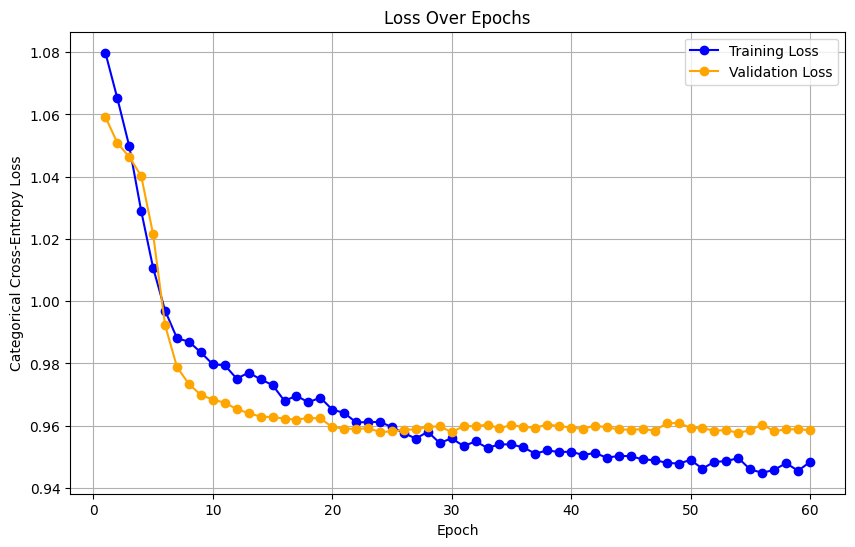

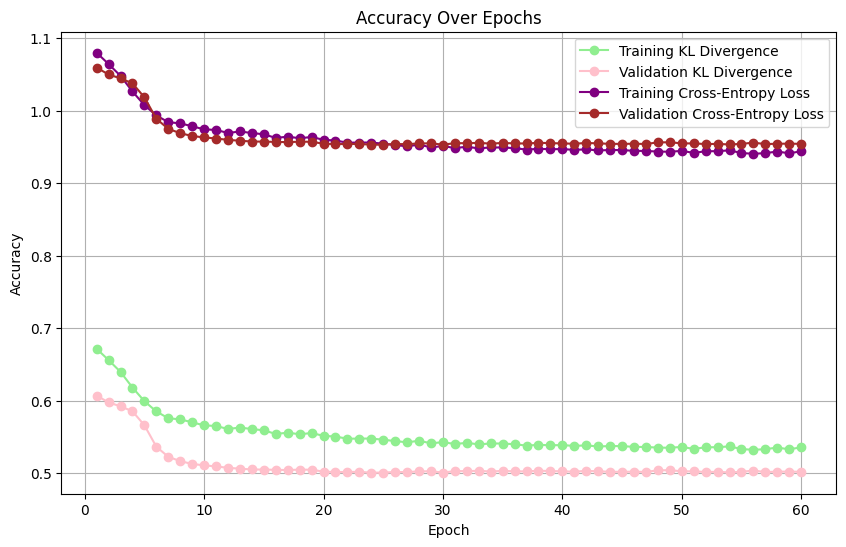

In [47]:
history = model.fit(
    [X_train, horizon_train], Y_train,
    validation_data=([X_valid, horizon_valid], Y_valid),
    callbacks=[AnnealingCallback()],
    epochs=60,  # Use the same number as in your tuner setup
    verbose=1  # Set to 0 for silent output if preferred
)

def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Plot Loss
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o', color='blue')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='o', color='orange')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Plot Accuracy
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history.history['evidential_kl_divergence'], label='Training KL Divergence', marker='o', color='lightgreen')
    plt.plot(epochs, history.history['val_evidential_kl_divergence'], label='Validation KL Divergence', marker='o', color='pink')
    plt.plot(epochs, history.history['cross_entropy_loss'], label='Training Cross-Entropy Loss', marker='o', color='purple')
    plt.plot(epochs, history.history['val_cross_entropy_loss'], label='Validation Cross-Entropy Loss', marker='o', color='brown')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_training_history(history)